# Input
runs, balls_played, 4s, 6s

# Nodes
system will calculate 3 matrics which are independent of each other
strike rate, boundry_%, balls_per_boundry, summary of matrics

# output
output state will contain input/initial variables additionally three matrics, summary

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


In [2]:

# ====================== 1. Define State ======================
class CricketState(TypedDict):
    runs: int
    balls_played: int
    fours: int
    sixes: int
    strike_rate: float
    boundary_percentage: float
    balls_per_boundary: float
    summary: str


In [3]:

# ====================== 2. Define Nodes (Independent) ======================

def calculate_strike_rate(state: CricketState) -> CricketState:
    sr = (state["runs"] / state["balls_played"]) * 100 if state["balls_played"] > 0 else 0.0
    return {"strike_rate": round(sr, 2)}

def calculate_boundary_percentage(state: CricketState) -> CricketState:
    total_boundaries = state["fours"] + state["sixes"]
    bp = (total_boundaries / state["balls_played"]) * 100 if state["balls_played"] > 0 else 0.0
    return {"boundary_percentage": round(bp, 2)}

def calculate_balls_per_boundary(state: CricketState) -> CricketState:
    total_boundaries = state["fours"] + state["sixes"]
    bpb = state["balls_played"] / total_boundaries if total_boundaries > 0 else 0.0
    return {"balls_per_boundary": round(bpb, 2)}

def generate_summary(state: CricketState) -> CricketState:
    summary = f"""
Cricket Performance Summary:
- Runs: {state['runs']} in {state['balls_played']} balls
- Strike Rate: {state['strike_rate']:.2f}
- Boundary Percentage: {state['boundary_percentage']:.2f}%
- Balls per Boundary: {state['balls_per_boundary']:.2f}
    """.strip()
    
    return {"summary": summary}



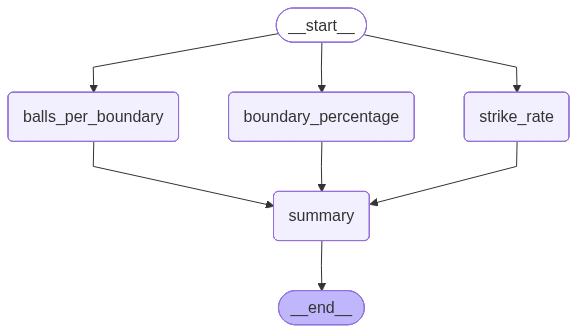

In [5]:
# ====================== 3. Build the Graph ======================

graph = StateGraph(CricketState)

# Add all nodes
graph.add_node("strike_rate", calculate_strike_rate)
graph.add_node("boundary_percentage", calculate_boundary_percentage)
graph.add_node("balls_per_boundary", calculate_balls_per_boundary)
graph.add_node("summary", generate_summary)

# Parallel execution: Connect START to all three calculation nodes
graph.add_edge(START, "strike_rate")
graph.add_edge(START, "boundary_percentage")
graph.add_edge(START, "balls_per_boundary")

# After all three finish → go to summary node
graph.add_edge("strike_rate", "summary")
graph.add_edge("boundary_percentage", "summary")
graph.add_edge("balls_per_boundary", "summary")

# Final output
graph.add_edge("summary", END)

# Compile the workflow
workflow = graph.compile()
workflow

In [6]:

# ====================== 4. Run the Workflow ======================

initial_state = {
    "runs": 85,
    "balls_played": 62,
    "fours": 7,
    "sixes": 3,
    "strike_rate": 0.0,
    "boundary_percentage": 0.0,
    "balls_per_boundary": 0.0,
    "summary": ""
}

result = workflow.invoke(initial_state)

print("=== Final Output ===")
print(f"Runs               : {result['runs']}")
print(f"Balls Played       : {result['balls_played']}")
print(f"Strike Rate        : {result['strike_rate']}")
print(f"Boundary %         : {result['boundary_percentage']}%")
print(f"Balls per Boundary : {result['balls_per_boundary']}")
print("\nSummary:")
print(result['summary'])

=== Final Output ===
Runs               : 85
Balls Played       : 62
Strike Rate        : 137.1
Boundary %         : 16.13%
Balls per Boundary : 6.2

Summary:
Cricket Performance Summary:
- Runs: 85 in 62 balls
- Strike Rate: 137.10
- Boundary Percentage: 16.13%
- Balls per Boundary: 6.20


In [18]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import HumanMessage
from dotenv import load_dotenv

import os

In [19]:
# Check if API key is loaded
if not os.getenv("GROQ_API_KEY"):
    print("❌ GROQ_API_KEY not found!")
    print("Please add your key to .env file or set it manually below.")
else:
    print("✅ GROQ_API_KEY loaded successfully")

❌ GROQ_API_KEY not found!
Please add your key to .env file or set it manually below.


In [10]:

# ====================== 1. State ======================
class ResearchState(TypedDict):
    query: str
    search_results: str
    optimistic_analysis: str
    pessimistic_analysis: str
    balanced_analysis: str
    final_report: str

# ====================== 2. Nodes ======================
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.7, max_tokens=1024)

# Tool for web search (best for agents in 2026)
search_tool = TavilySearchResults(max_results=5)

def web_search_node(state: ResearchState) -> ResearchState:
    results = search_tool.invoke(state["query"])
    return {"search_results": results}

def optimistic_node(state: ResearchState) -> ResearchState:
    prompt = f"""You are an optimistic strategist. Give a deep, positive, forward-looking analysis of this query.
Use the search results if available.

Query: {state['query']}
Search Results: {state.get('search_results', 'No results yet')}

Focus on opportunities, breakthroughs, and best-case scenarios."""
    
    response = llm.invoke([HumanMessage(content=prompt)])
    return {"optimistic_analysis": response.content}

def pessimistic_node(state: ResearchState) -> ResearchState:
    prompt = f"""You are a critical risk analyst. Give a deep, cautious, pessimistic analysis of this query.
Highlight risks, downsides, failure modes, and worst-case scenarios.

Query: {state['query']}
Search Results: {state.get('search_results', 'No results yet')}"""
    
    response = llm.invoke([HumanMessage(content=prompt)])
    return {"pessimistic_analysis": response.content}

def balanced_node(state: ResearchState) -> ResearchState:
    prompt = f"""You are a neutral, data-driven analyst. Give a deep, realistic, balanced analysis of this query.
Weigh pros/cons objectively using the search results.

Query: {state['query']}
Search Results: {state.get('search_results', 'No results yet')}"""
    
    response = llm.invoke([HumanMessage(content=prompt)])
    return {"balanced_analysis": response.content}

def synthesize_node(state: ResearchState) -> ResearchState:
    prompt = f"""You are an expert research synthesizer. Create a comprehensive, balanced final report.

Query: {state['query']}

Search Results:
{state.get('search_results', '')}

Optimistic View:
{state.get('optimistic_analysis', '')}

Pessimistic View:
{state.get('pessimistic_analysis', '')}

Balanced View:
{state.get('balanced_analysis', '')}

Structure the report with:
1. Executive Summary
2. Key Facts from Web
3. Multi-Perspective Insights
4. Recommendations & Risks
5. Final Verdict"""

    response = llm.invoke([HumanMessage(content=prompt)])
    return {"final_report": response.content}

# ====================== 3. Build Parallel Graph ======================
graph = StateGraph(ResearchState)

graph.add_node("web_search", web_search_node)
graph.add_node("optimistic", optimistic_node)
graph.add_node("pessimistic", pessimistic_node)
graph.add_node("balanced", balanced_node)
graph.add_node("synthesize", synthesize_node)

# ←←← PARALLEL EXECUTION STARTS HERE
graph.add_edge(START, "web_search")
graph.add_edge(START, "optimistic")
graph.add_edge(START, "pessimistic")
graph.add_edge(START, "balanced")

# All 4 nodes must finish before synthesis
graph.add_edge("web_search", "synthesize")
graph.add_edge("optimistic", "synthesize")
graph.add_edge("pessimistic", "synthesize")
graph.add_edge("balanced", "synthesize")

graph.add_edge("synthesize", END)

workflow = graph.compile()

# Optional: Visualize the parallel structure
# print(workflow.get_graph().draw_mermaid())

GroqError: The api_key client option must be set either by passing api_key to the client or by setting the GROQ_API_KEY environment variable

In [ ]:
result = workflow.invoke({
    "query": "Should a software developer in Pakistan switch to AI engineering in 2026?",
    "search_results": "",
    "optimistic_analysis": "",
    "pessimistic_analysis": "",
    "balanced_analysis": "",
    "final_report": ""
})

print(result["final_report"])